In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn import datasets
iris=datasets.load_iris()

In [4]:
x=iris["data"][:,0].reshape(-1,1)
y=(iris["target"]==0).astype(int)

In [5]:
from sklearn.linear_model import LogisticRegression
log_reg=LogisticRegression(solver="lbfgs",C=.1,random_state=1)
log_reg.fit(x,y)

LogisticRegression(C=0.1, random_state=1)

In [6]:
y_pred=log_reg.predict(x)

In [9]:
from sklearn.metrics import confusion_matrix,precision_score,recall_score,f1_score
confusion_matrix(y,y_pred)

array([[94,  6],
       [11, 39]])

In [11]:
precision_score(y,y_pred)

0.8666666666666667

In [12]:
recall_score(y,y_pred)

0.78

In [13]:
f1_score(y,y_pred)

0.8210526315789474

In [14]:
log_reg.intercept_+log_reg.coef_*x[0]

array([[0.19647482]])

In [15]:
h=log_reg.decision_function(x)
h[0]

np.float64(0.1964748180723479)

In [16]:
threshold=0.1

y_pred_mod=(h>threshold).astype(int)
y_pred_mod

array([1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [17]:
confusion_matrix(y,y_pred_mod)

array([[95,  5],
       [14, 36]])

In [18]:
precision_score(y,y_pred_mod)

0.8780487804878049

In [19]:
recall_score(y,y_pred_mod)

0.72

In [20]:
f1_score(y,y_pred_mod)

0.7912087912087912

In [21]:
from sklearn.metrics import precision_recall_curve
precisions,recalls,thresholds=precision_recall_curve(y,h)

In [22]:
thresholds

array([-4.0925941 , -3.78623203, -3.633051  , -3.32668893, -3.1735079 ,
       -3.02032687, -2.86714584, -2.7139648 , -2.56078377, -2.40760274,
       -2.25442171, -2.10124067, -1.94805964, -1.79487861, -1.64169757,
       -1.48851654, -1.33533551, -1.18215448, -1.02897344, -0.87579241,
       -0.72261138, -0.56943035, -0.41624931, -0.26306828, -0.10988725,
        0.04329379,  0.19647482,  0.34965585,  0.50283688,  0.65601792,
        0.80919895,  0.96237998,  1.11556101,  1.26874205,  1.42192308])

In [23]:
precisions

array([0.33333333, 0.33557047, 0.34482759, 0.34722222, 0.34965035,
       0.35211268, 0.35971223, 0.36231884, 0.3649635 , 0.37593985,
       0.38461538, 0.40983607, 0.41666667, 0.43478261, 0.46296296,
       0.50505051, 0.52631579, 0.56179775, 0.60240964, 0.625     ,
       0.67123288, 0.72307692, 0.79661017, 0.86538462, 0.86956522,
       0.86666667, 0.87804878, 0.875     , 0.90909091, 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        ])

In [24]:
recalls

array([1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  ,
       1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 0.98, 0.94,
       0.94, 0.9 , 0.8 , 0.78, 0.72, 0.56, 0.4 , 0.32, 0.22, 0.18, 0.1 ,
       0.08, 0.02, 0.  ])

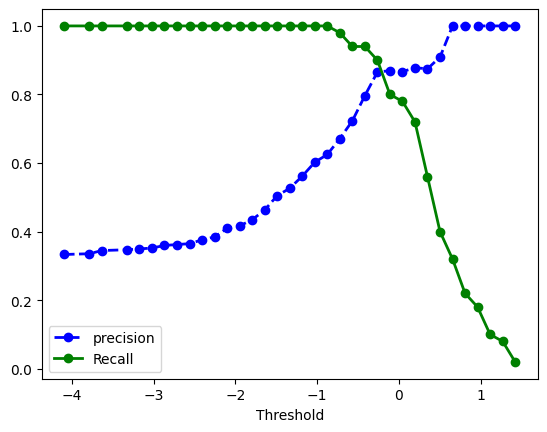

In [27]:
plt.plot(thresholds,precisions[:-1],"bo--",label="precision",linewidth=2)
plt.plot(thresholds,recalls[:-1],"go-",label="Recall",linewidth=2)
plt.xlabel("Threshold")
plt.legend()
plt.show()

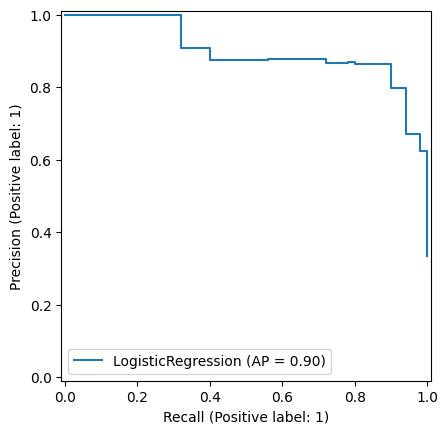

In [30]:
from sklearn.metrics import PrecisionRecallDisplay
PrecisionRecallDisplay.from_estimator(log_reg,x,y)
plt.show()

In [31]:
from sklearn.metrics import roc_curve

fpr,tpr,thresholds=roc_curve(y,h)

In [32]:
fpr

array([0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.02, 0.04, 0.05, 0.06,
       0.06, 0.07, 0.12, 0.18, 0.24, 0.3 , 0.33, 0.45, 0.49, 0.58, 0.65,
       0.7 , 0.72, 0.8 , 0.83, 0.87, 0.89, 0.92, 0.95, 0.99, 1.  ])

In [33]:
tpr

array([0.  , 0.02, 0.08, 0.1 , 0.18, 0.22, 0.32, 0.4 , 0.56, 0.72, 0.78,
       0.8 , 0.9 , 0.94, 0.94, 0.98, 1.  , 1.  , 1.  , 1.  , 1.  , 1.  ,
       1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  ])

In [34]:
thresholds

array([        inf,  1.42192308,  1.26874205,  1.11556101,  0.96237998,
        0.80919895,  0.65601792,  0.50283688,  0.34965585,  0.19647482,
        0.04329379, -0.10988725, -0.26306828, -0.41624931, -0.56943035,
       -0.72261138, -0.87579241, -1.02897344, -1.33533551, -1.48851654,
       -1.64169757, -1.79487861, -1.94805964, -2.10124067, -2.25442171,
       -2.40760274, -2.56078377, -2.86714584, -3.02032687, -3.633051  ,
       -3.78623203, -4.0925941 ])

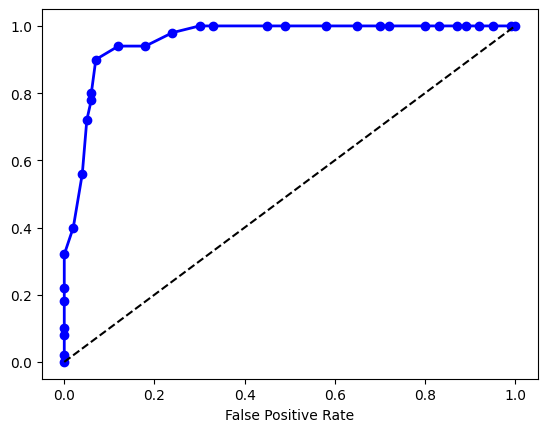

In [35]:
plt.plot(fpr,tpr,'bo-',linewidth=2,label='roc_curve_plot')
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.show()

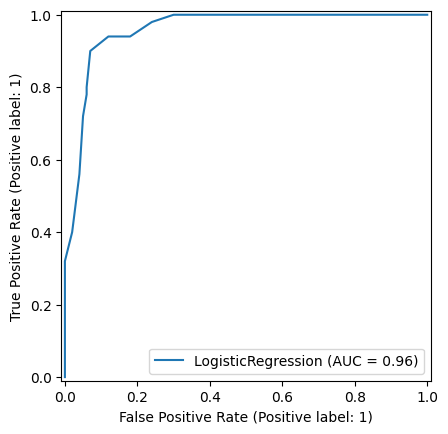

In [37]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(log_reg, x, y)
plt.show()

In [38]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y,h)

np.float64(0.9586)